# Setup y Exploración de Datos (EDA)

## 1. Sección de Setup

Instalación de las dependencias requeridas para el proyecto.

In [3]:
# Instalar dependencias desde requirements.txt y librerías de visualización
%pip install -r ../requirements.txt
%pip install matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 48.3 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 235.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 765.1/765.1 kB 29.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 185.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 158.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 26.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 93.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 243.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 209.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 306.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.6/797.6 kB 38.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━

Descarga de los recursos de NLTK necesarios (como las stopwords para el procesamiento de texto).

In [4]:
import nltk

print("Descargando recursos necesarios de NLTK...")
nltk.download('stopwords')
nltk.download('punkt')
print("¡Descarga de recursos completada!")

Descargando recursos necesarios de NLTK...


[nltk_data] Downloading package stopwords to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


¡Descarga de recursos completada!


Verificación de que `faiss-cpu` está correctamente importado en el entorno de ejecución.

In [5]:
try:
    import faiss
    print(f"FAISS importado exitosamente. Versión: {faiss.__version__}")
except ImportError as e:
    print(f"Error al importar FAISS: {e}. Asegúrate de haber instalado 'faiss-cpu'.")

FAISS importado exitosamente. Versión: 1.14.3


## 2. Exploración de Datos (EDA)

Carga de los datasets unificados de las distintas plataformas y filtrado de las películas.

In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

datasets_dir = '../data/Datasets'
platform_mapping = {
    'amazon_prime_titles.csv': 'Amazon Prime',
    'disney_plus_titles.csv': 'Disney+',
    'hulu_titles.csv': 'Hulu',
    'netflix_titles.csv': 'Netflix'
}

dfs = []
for file, platform_name in platform_mapping.items():
    path = os.path.join(datasets_dir, file)
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['platform'] = platform_name
        dfs.append(df)

all_data = pd.concat(dfs, ignore_index=True)
print(f"Total de registros unificados: {len(all_data)}")

movies = all_data[all_data['type'] == 'Movie'].copy()
print(f"Total de películas: {len(movies)}")

Total de registros unificados: 22998
Total de películas: 16481


### 2.1 Distribución de Películas por Plataforma de Origen

/tmp/ipykernel_10617/2401676570.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_counts.index, y=platform_counts.values, palette=palette)


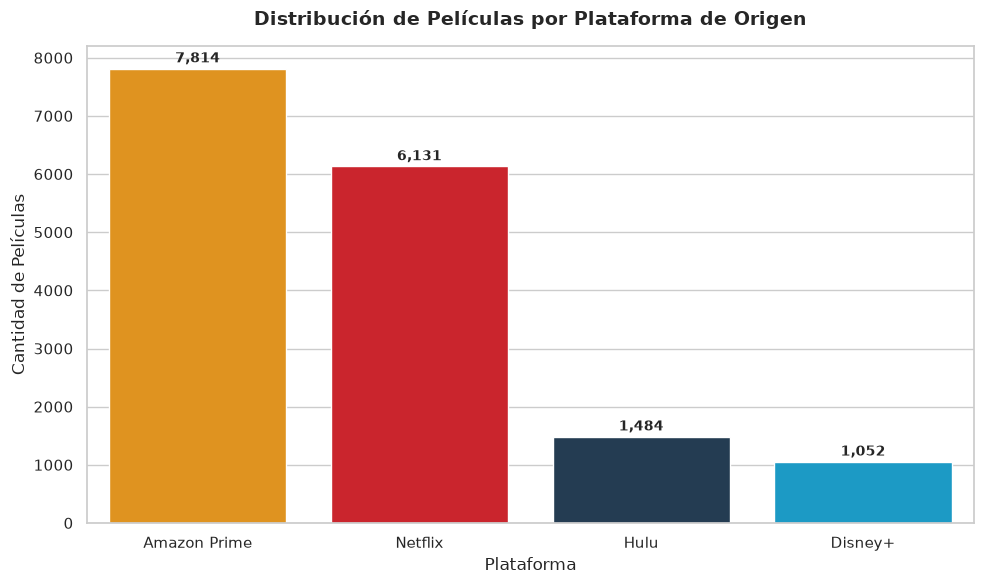

In [7]:
# Distribución de películas por plataforma
platform_counts = movies['platform'].value_counts()

plt.figure(figsize=(10, 6))
color_map = {
    'Netflix': '#E50914',      
    'Amazon Prime': '#FF9900', 
    'Hulu': '#1C3D5A',         
    'Disney+': '#00A8E1'       
}
palette = [color_map.get(x, '#6C757D') for x in platform_counts.index]

sns.barplot(x=platform_counts.index, y=platform_counts.values, palette=palette)
plt.title('Distribución de Películas por Plataforma de Origen', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Cantidad de Películas', fontsize=12)

for i, v in enumerate(platform_counts.values):
    plt.text(i, v + 50, f"{v:,}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.2 Cantidad de Lanzamientos de Películas a lo largo de los Años

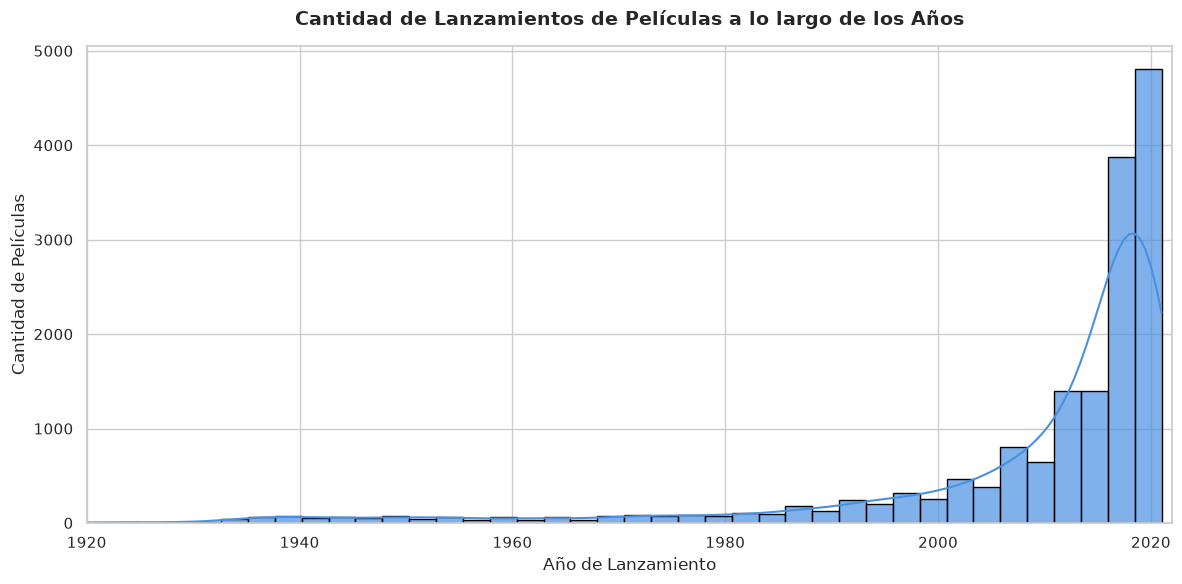

In [8]:
plt.figure(figsize=(12, 6))
sns.histplot(data=movies, x='release_year', bins=40, kde=True, color='#4A90E2', edgecolor='black', alpha=0.7)
plt.title('Cantidad de Lanzamientos de Películas a lo largo de los Años', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Cantidad de Películas', fontsize=12)
plt.xlim(movies['release_year'].min(), movies['release_year'].max() + 1)
plt.tight_layout()
plt.show()

### 2.3 Frecuencia de los Géneros más Populares

/tmp/ipykernel_10617/1880714389.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_genres, y='Género', x='Frecuencia', palette='viridis')


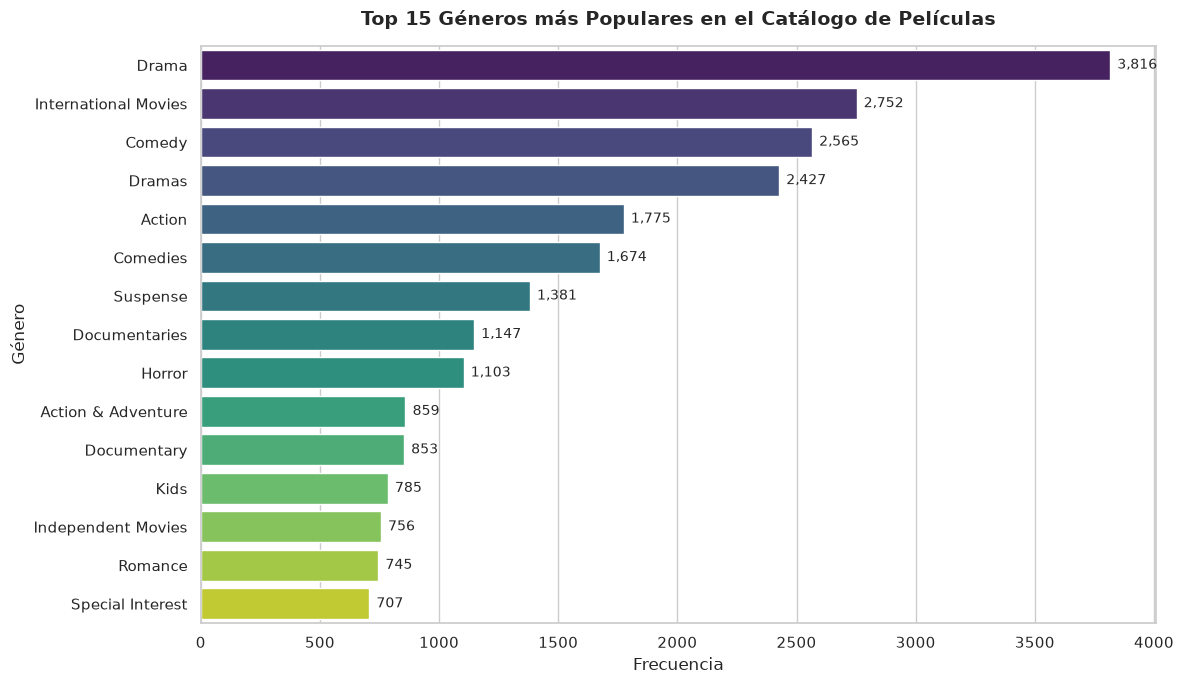

In [9]:
from collections import Counter

genre_list = movies['listed_in'].dropna().str.split(',')
flat_genres = [genre.strip() for sublist in genre_list for genre in sublist if genre.strip()]
genre_counts = Counter(flat_genres).most_common(15)

df_genres = pd.DataFrame(genre_counts, columns=['Género', 'Frecuencia'])

plt.figure(figsize=(12, 7))
sns.barplot(data=df_genres, y='Género', x='Frecuencia', palette='viridis')
plt.title('Top 15 Géneros más Populares en el Catálogo de Películas', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Género', fontsize=12)

for i, v in enumerate(df_genres['Frecuencia']):
    plt.text(v + 30, i, f"{v:,}", ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 2.4 Análisis de Longitud de Textos (Cantidad de palabras en las sinopsis)

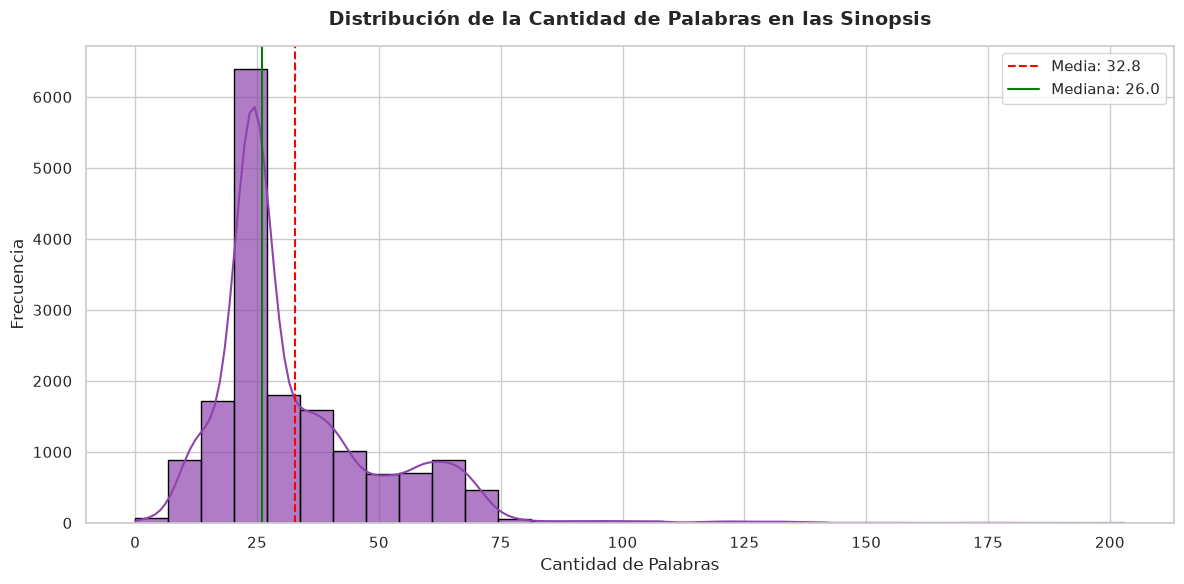

In [10]:
movies['word_count'] = movies['description'].fillna('').apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.histplot(data=movies, x='word_count', bins=30, kde=True, color='#8E44AD', edgecolor='black', alpha=0.7)
plt.title('Distribución de la Cantidad de Palabras en las Sinopsis', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Palabras', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

mean_len = movies['word_count'].mean()
median_len = movies['word_count'].median()
plt.axvline(mean_len, color='red', linestyle='--', linewidth=1.5, label=f'Media: {mean_len:.1f}')
plt.axvline(median_len, color='green', linestyle='-', linewidth=1.5, label=f'Mediana: {median_len:.1f}')

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()